In [ ]:
import sys

import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import shap

sys.path.insert(0, "../..")

from probability_prediction.calibration.calibration_plots import calibration_diagnostics
from probability_prediction.calibration.calibrator import Calibrator
from probability_prediction.ability_prediction.ability_prediction.ability_prediction.ability_prediction.utils import calculate_brier_metrics, get_best_f1, ice_pdp_plot, stochastic_baseline, deterministic_baseline

c:\Users\arfabreg\OneDrive - Capgemini\Documents\churn_proba\probability_estimation\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load and EDA

In [2]:
# Dataset creation
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)

df = data["data"].copy()
df["target"] = data["target"]

# 1=malignant, 0=benign
df["target"] = df["target"] + 1
df.loc[df["target"] == 2, "target"] = 0

In [3]:
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,1
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,1
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,1
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,1


In [4]:
# Separate target
y = df["target"].values.astype(np.float32)
X = df.drop(columns=["target"])

In [5]:
ir_tr = float((y == 0).sum() / (y == 1).sum())
n0, n1 = (y == 0).sum(), (y == 1).sum()
mayoritary_label = 0.0 if n0 >= n1 else 1.0

print(f"Imbalance Ratio: {ir_tr:.2f} (n0={n0}, n1={n1})")

Imbalance Ratio: 1.68 (n0=357, n1=212)


In [6]:
# Train / validation / test split
x_tr, x_val_test, y_tr, y_val_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
x_val, x_test, y_val, y_test = train_test_split(
    x_val_test, y_val_test, test_size=0.5, random_state=42, stratify=y_val_test
)

## Init and fit the model

In [7]:
# Define the xgboost
all_vars = list(x_tr.columns)  # must match column order
non_mon_vars = [
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean smoothness",
    "mean compactness",
    "mean concavity",
    "mean concave points",
    "mean symmetry",
    "mean fractal dimension",
    "radius error",
    "texture error",
    "perimeter error",
    "area error",
    "compactness error",
    "concavity error",
    "concave points error",
    "symmetry error",
    "fractal dimension error",
    "worst radius",
    "worst texture",
    "worst perimeter",
    "worst area",
    "worst smoothness",
    "worst compactness",
    "worst concavity",
    "worst concave points",
    "worst symmetry",
    "worst fractal dimension",
]
pos_mon_vars = ["mean radius"]
neg_mon_vars = ["smoothness error"]

# XGBoost requires a list of integers in the exact order of the feature columns:
mono_constraints = []
for col in all_vars:
    if col in pos_mon_vars:
        mono_constraints.append(1)
    elif col in neg_mon_vars:
        mono_constraints.append(-1)
    else:
        mono_constraints.append(0)

model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    monotone_constraints=tuple(mono_constraints),
    scale_pos_weight=1.0,
    tree_method="hist",  # fast + supports monotonicity
    max_depth=5,
    learning_rate=0.05,
    n_estimators=200,
    subsample=0.8,
    colsample_bytree=0.8,
)

In [8]:
# Fit the model
model.fit(
    x_tr,
    y_tr,
    eval_set=[(x_val, y_val)],
    verbose=False,
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

## Model evaluation

In [9]:
# Probabilistic benchmarks
_, _, _, f1_stock = stochastic_baseline(p=y_tr.mean())
_, _, _, f1_det = deterministic_baseline(p=y_tr.mean())

=== STOCHASTIC BASELINE ===
Confusion matrix:
 [[29 27]
 [28 16]]
Precision=0.372, Recall=0.364, F1=0.368


=== DETERMINISTIC BASELINE ===
Confusion matrix:
 [[ 0 63]
 [ 0 37]]
Precision=0.370, Recall=1.000, F1=0.540


In [10]:
# Predict probs on train/validation/test set
probs_tr = model.predict_proba(x_tr)[:, 1]
probs_val = model.predict_proba(x_val)[:, 1]
probs_test = model.predict_proba(x_test)[:, 1]

# Compute best threshold & F1
best_t_tr, best_f1_tr, f1_tr_curve, thresholds = get_best_f1(y_tr, probs_tr)
best_t_val, best_f1_val, f1_val_curve, _ = get_best_f1(y_val, probs_val)
best_t_test, best_f1_test, f1_test_curve, _ = get_best_f1(y_test, probs_test)

print("- Train best F1:", round(best_f1_tr, 4), "at threshold", round(best_t_tr, 4), f"| {best_f1_tr/f1_stock:.2f} times better than stochastic | {best_f1_tr/f1_det:.2f} times better than deterministic")
print("- Val best F1:", round(best_f1_val, 4), "at threshold", round(best_t_val, 4), f"| {best_f1_val/f1_stock:.2f} times better than stochastic | {best_f1_val/f1_det:.2f} times better than deterministic")
print("- Test best F1:", round(best_f1_test, 4), "at threshold", round(best_t_test, 4), f"| {best_f1_test/f1_stock:.2f} times better than stochastic | {best_f1_test/f1_det:.2f} times better than deterministic")

- Train best F1: 1.0 at threshold 0.1859 | 2.72 times better than stochastic | 1.85 times better than deterministic
- Val best F1: 0.9841 at threshold 0.2362 | 2.68 times better than stochastic | 1.82 times better than deterministic
- Test best F1: 1.0 at threshold 0.1106 | 2.72 times better than stochastic | 1.85 times better than deterministic


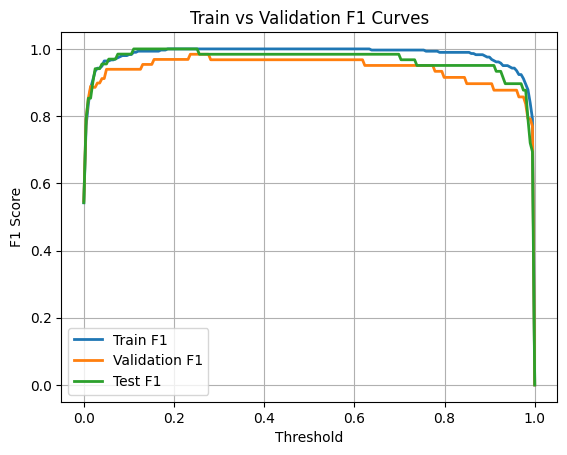

In [11]:
plt.plot(thresholds, f1_tr_curve, label="Train F1", linewidth=2)
plt.plot(thresholds, f1_val_curve, label="Validation F1", linewidth=2)
plt.plot(thresholds, f1_test_curve, label="Test F1", linewidth=2)

plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Train vs Validation F1 Curves")
plt.legend()
plt.grid(True)
plt.show()

## Feature importance

C:\Users\arfabreg\AppData\Local\Temp\ipykernel_9988\2342199330.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, df, feature_names=df.columns)


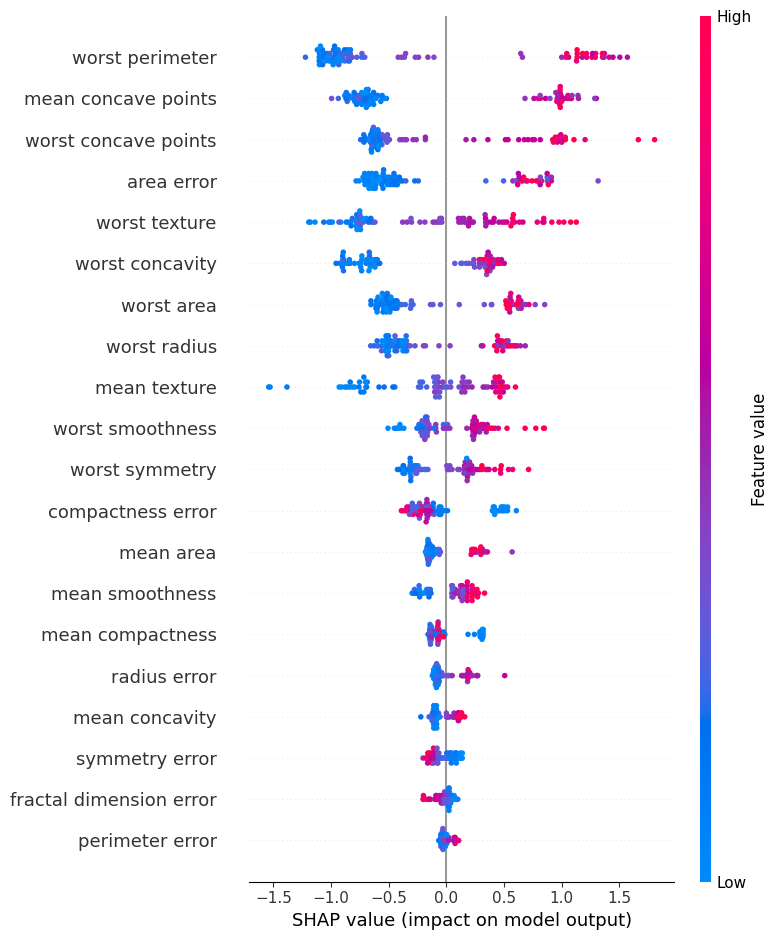

In [12]:
df = x_test.copy()

# Set the tree explainer as the model of the pipeline
explainer = shap.TreeExplainer(model)

# Get Shap values from preprocessed data
shap_values = explainer.shap_values(df)

# Plot the feature importance
shap.summary_plot(shap_values, df, feature_names=df.columns)
plt.show()

## Probability calibration

In [13]:
cal = Calibrator(method="isotonic")
cal.fit(probs_val, y_val)

probs_tr_cal = cal.predict_proba(probs_tr)
probs_val_cal = cal.predict_proba(probs_val)
probs_test_cal = cal.predict_proba(probs_test)

In [14]:
# Compute brier score - non calibrated probs
_, _, bss_tr, _ = calculate_brier_metrics(y_tr, probs_tr)
_, _, bss_val, _ = calculate_brier_metrics(y_val, probs_val)
_, _, bss_test, _ = calculate_brier_metrics(y_test, probs_test)
print("Non-calibrated probabilities")
print("- Train bss:", round(bss_tr, 4))
print("- Val bss:", round(bss_val, 4))
print("- Test bss:", round(bss_test, 4))

# Compute brier score - calibrated probs
_, _, bss_tr_cal, _ = calculate_brier_metrics(y_tr, probs_tr_cal)
_, _, bss_val_cal, _ = calculate_brier_metrics(y_val, probs_val_cal)
_, _, bss_test_cal, _ = calculate_brier_metrics(y_test, probs_test_cal)
print()
print("Calibrated probabilities")
print("- Train bss:", round(bss_tr_cal, 4))
print("- Val bss:", round(bss_val_cal, 4))
print("- Test bss:", round(bss_test_cal, 4))

Non-calibrated probabilities
- Train bss: 0.9942
- Val bss: 0.9067
- Test bss: 0.9623

Calibrated probabilities
- Train bss: 0.9949
- Val bss: 0.9555
- Test bss: 0.9842


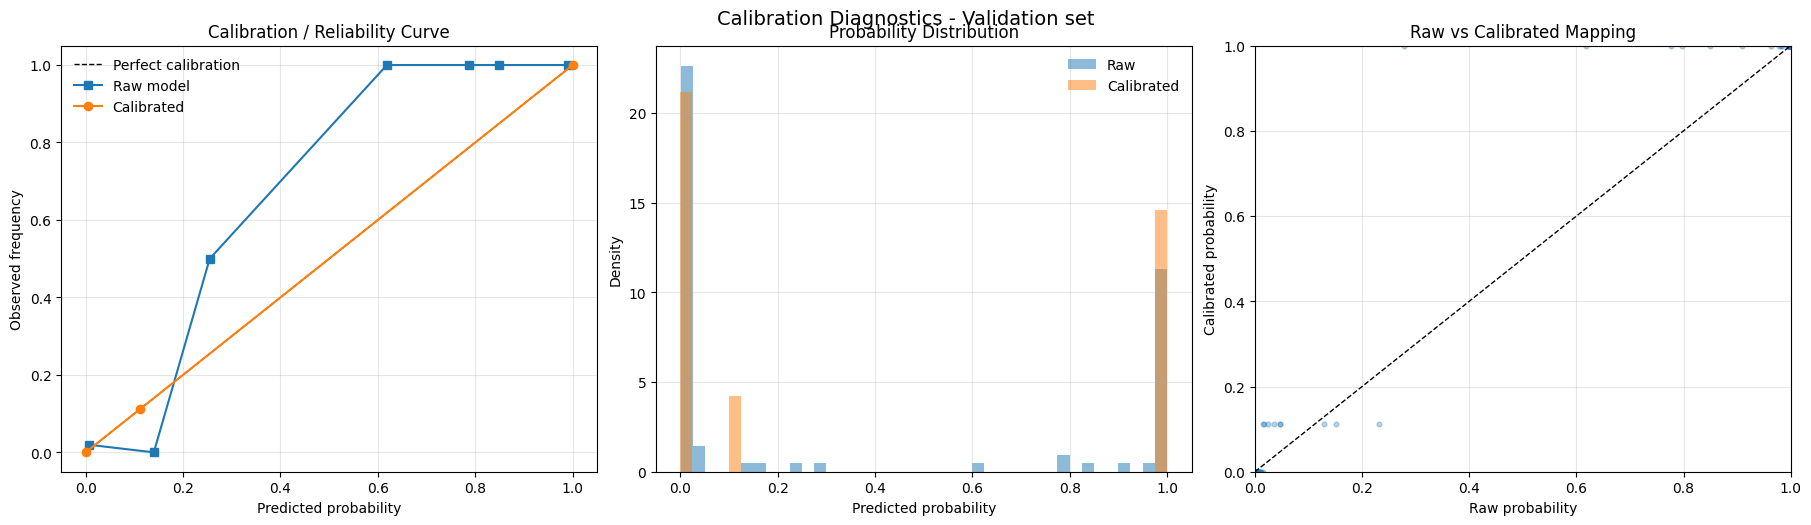

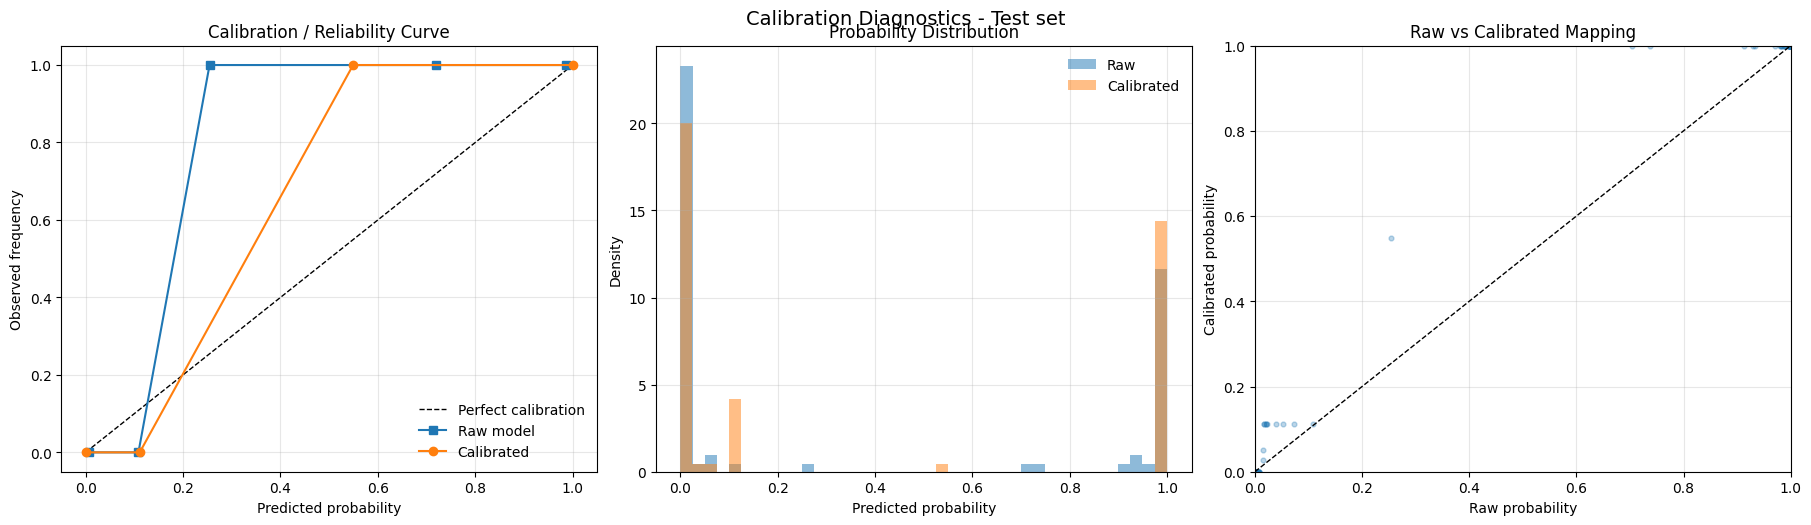

In [15]:
fig, axes = calibration_diagnostics(
    y_val, probs_val, probs_val_cal, n_bins=10, bins=40, suptitle="Calibration Diagnostics - Validation set"
)
fig, axes = calibration_diagnostics(
    y_test, probs_test, probs_test_cal, n_bins=10, bins=40, suptitle="Calibration Diagnostics - Test set"
)
plt.show()

## Partial dependncies

In [16]:
FEATURE_NAME = "mean radius"

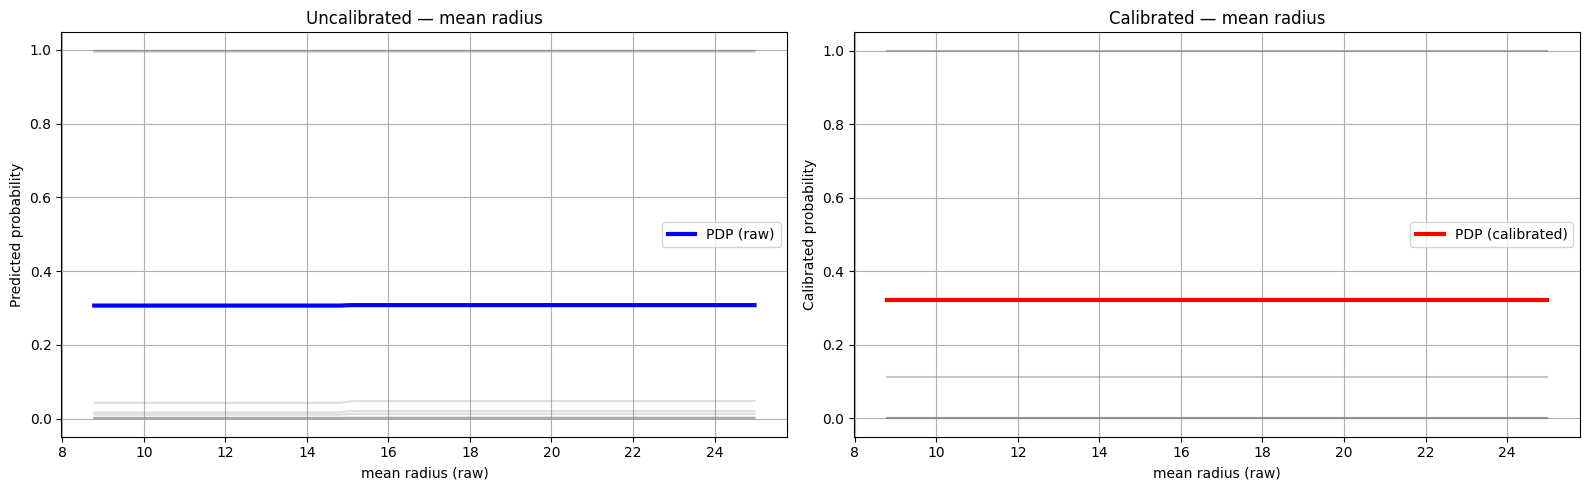

In [17]:
out = ice_pdp_plot(
    model=model,
    X_raw=x_val.values,
    X_std=x_val.values,
    feature_name=FEATURE_NAME,
    all_vars=all_vars,
    num_points=100,
    n_samples=10,
    calibrator=cal,
    model_input_space="raw",
)

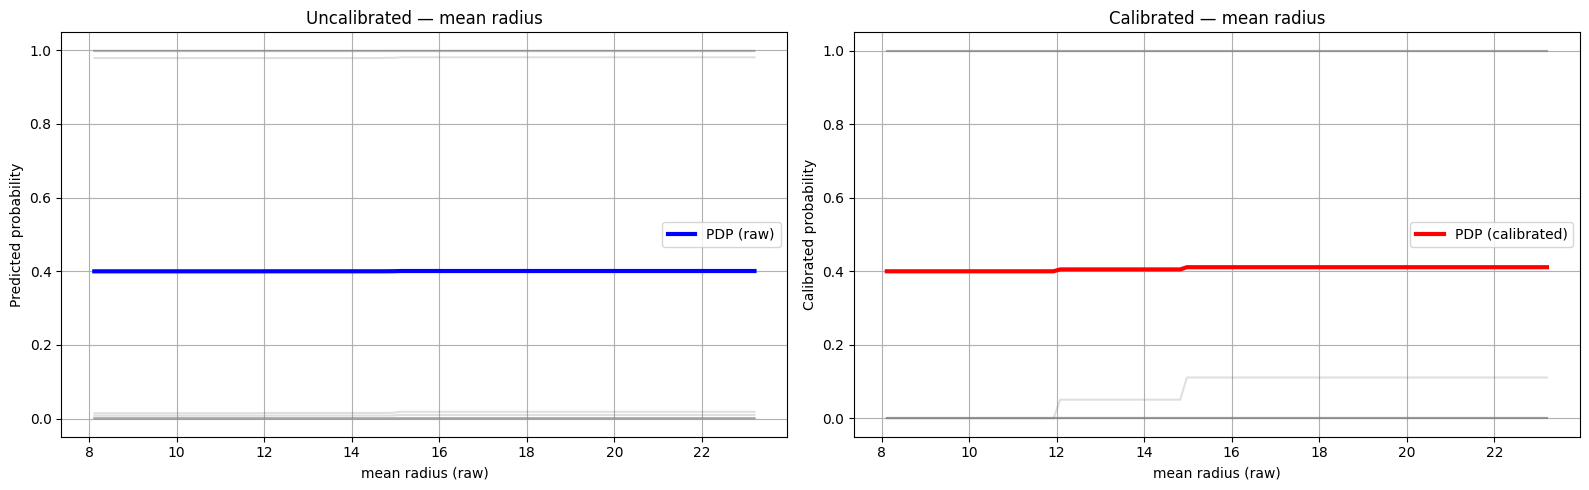

In [18]:
out = ice_pdp_plot(
    model=model,
    X_raw=x_test.values,
    X_std=x_test.values,
    feature_name=FEATURE_NAME,
    all_vars=all_vars,
    num_points=100,
    n_samples=10,
    calibrator=cal,
    model_input_space="raw",
)